# Audio Data

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Number of samples: 19311
Sample rate: 22050


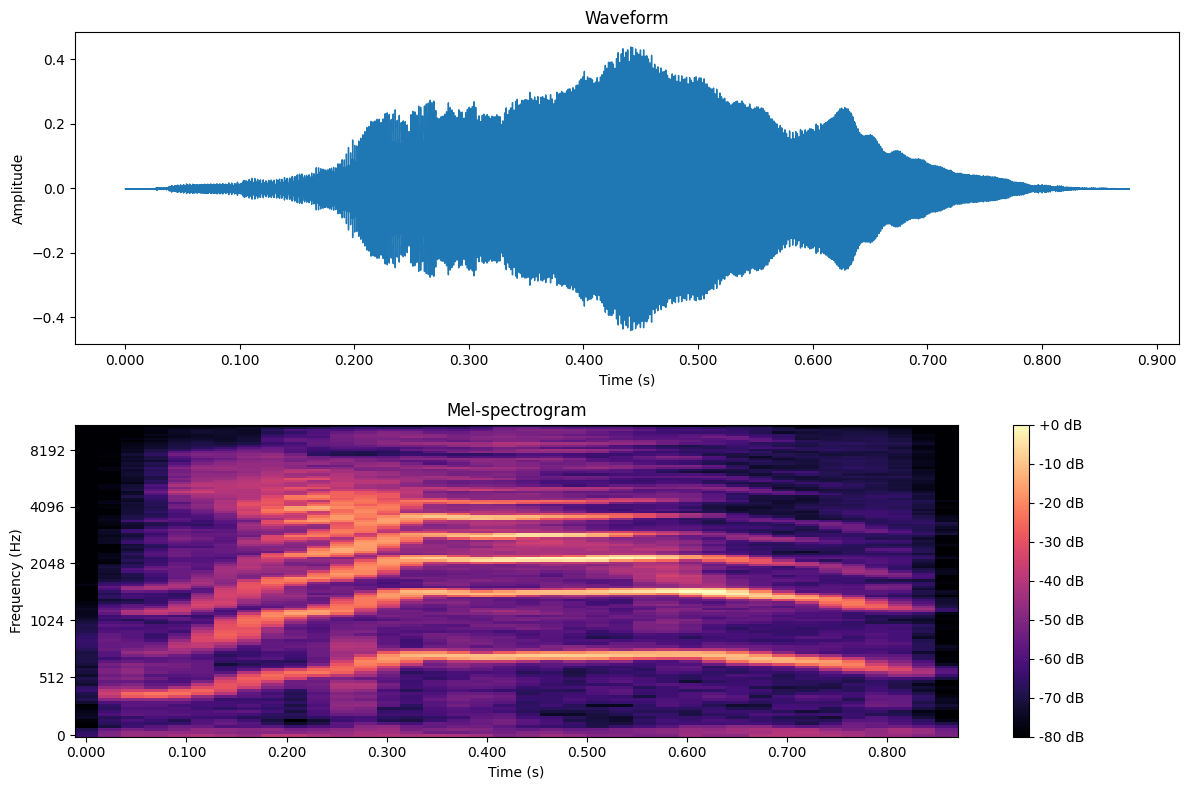

In [ ]:
import librosa
import librosa.display
import matplotlib.pyplot as plt
import numpy as np
from google.colab import drive
import os

# Mount Google Drive
drive.mount('/content/drive')

def plot_audio_visualizations(audio_path):
    # Load audio file
    y, sr = librosa.load(audio_path)

    print("Number of samples:", len(y))
    print("Sample rate:", sr)

    # Create figure with two subplots
    plt.figure(figsize=(12, 8))

    # Plot waveform
    plt.subplot(2, 1, 1)
    librosa.display.waveshow(y, sr=sr)
    plt.title('Waveform')
    plt.xlabel('Time (s)')
    plt.ylabel('Amplitude')

    # Compute mel-spectrogram
    mel_spect = librosa.feature.melspectrogram(y=y, sr=sr)
    mel_spect_db = librosa.power_to_db(mel_spect, ref=np.max)

    # Plot mel-spectrogram
    plt.subplot(2, 1, 2)
    librosa.display.specshow(mel_spect_db, sr=sr, x_axis='time', y_axis='mel')
    plt.colorbar(format='%+2.0f dB')
    plt.title('Mel-spectrogram')
    plt.xlabel('Time (s)')
    plt.ylabel('Frequency (Hz)')

    plt.tight_layout()
    plt.show()

# Example usage
audio_file = "/content/drive/MyDrive/DPI-UFV/Disciplinas/2024-2/INF721/cat.wav"  # Update this path
plot_audio_visualizations(audio_file)

#CLIP (Contrastive Language-Image Pre-training)

In [ ]:
from transformers import CLIPProcessor, CLIPModel
import torch
from PIL import Image
from google.colab import drive
import os

model = CLIPModel.from_pretrained("openai/clip-vit-base-patch32")
processor = CLIPProcessor.from_pretrained("openai/clip-vit-base-patch32")

# Mount Google Drive
drive.mount('/content/drive')
image_file = "/content/drive/MyDrive/DPI-UFV/Disciplinas/2024-2/INF721/cat.png"  # Update this path

image = Image.open(image_file)
text = ["a photo of a cat", "a photo of a dog"]
inputs = processor(images=image, text=text, return_tensors="pt")
outputs = model(**inputs)

# Print raw similarity scores
similarities = outputs.logits_per_image[0]
for text_class, similarity in zip(text, similarities):
   print(f"Similarity with '{text_class}': {similarity.item():.2f}")

# Get probabilities
probs = outputs.logits_per_image.softmax(dim=1)

# Print classification results
for text_class, prob in zip(text, probs[0]):
   print(f"{text_class}: {prob.item():.2%}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Similarity with 'a photo of a cat': 26.91
Similarity with 'a photo of a dog': 22.56
a photo of a cat: 98.72%
a photo of a dog: 1.28%
